<a href="https://www.kaggle.com/code/stutisharma22/predicting-road-accident-risk?scriptVersionId=265754836" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

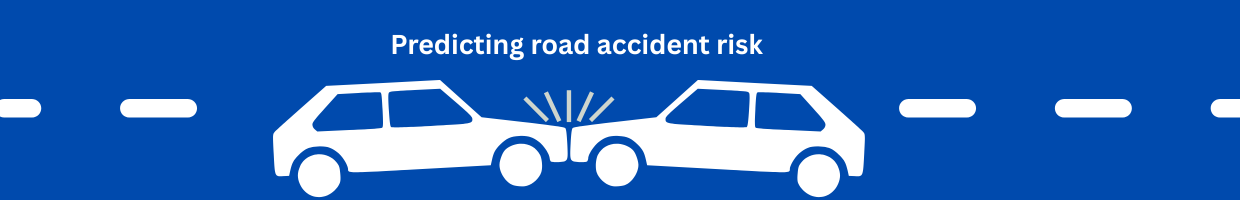

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


**Importing required libraries**

In [2]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from math import sqrt

**Loading the data**

In [3]:
#reading data from the files
df_train= pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
df_test= pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

In [4]:
#resetting the index
df_train= df_train.set_index('id')
df_test= df_test.set_index('id')

**Exploratory data analysis**

In [5]:
#viewing first five rows of the dataset
df_train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [6]:
#number of columns and data types in the train dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 517754 entries, 0 to 517753
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(3), object(4)
memory usage: 41.5+ MB


In [7]:
df_train.shape, df_test.shape

((517754, 13), (172585, 12))

In [8]:
#summary statistics of numerical columns in train dataset
df_train.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377
std,1.120434,0.272563,15.788521,0.895961,0.166417
min,1.000000,0.000000,25.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.230000
50%,2.000000,0.510000,45.000000,1.000000,0.340000
75%,3.000000,0.710000,60.000000,2.000000,0.460000
max,4.000000,1.000000,70.000000,7.000000,1.000000


In [9]:
#number of unique values in the columns
df_train.nunique()

road_type                   3
num_lanes                   4
curvature                 261
speed_limit                 5
lighting                    3
weather                     3
road_signs_present          2
public_road                 2
time_of_day                 3
holiday                     2
school_season               2
num_reported_accidents      8
accident_risk              98
dtype: int64

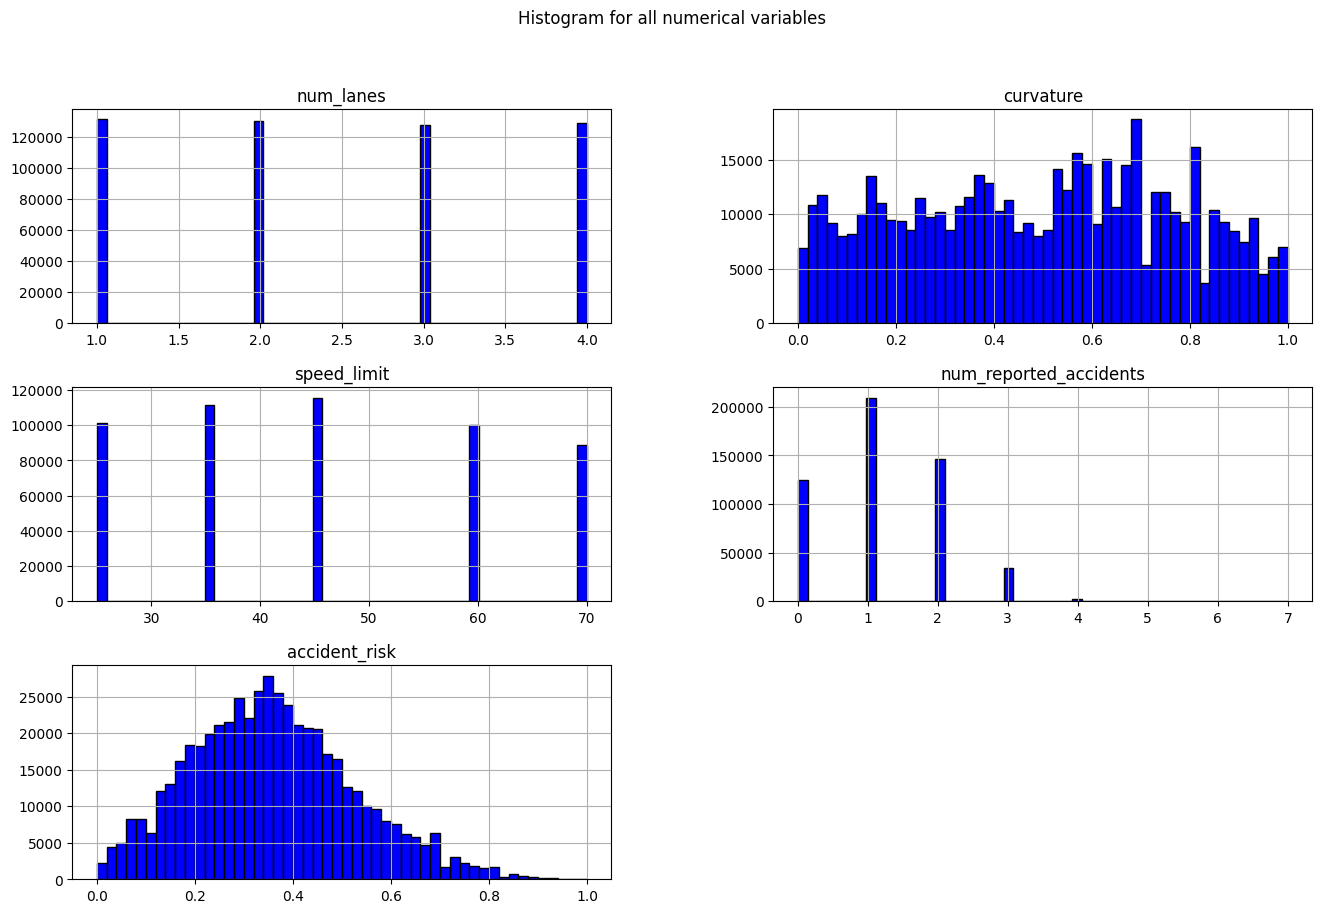

In [10]:
#plotting histogram for all the input variables
df_train.hist(figsize=(16,10), bins=50, color='blue', edgecolor='black')
plt.suptitle("Histogram for all numerical variables")
plt.show()

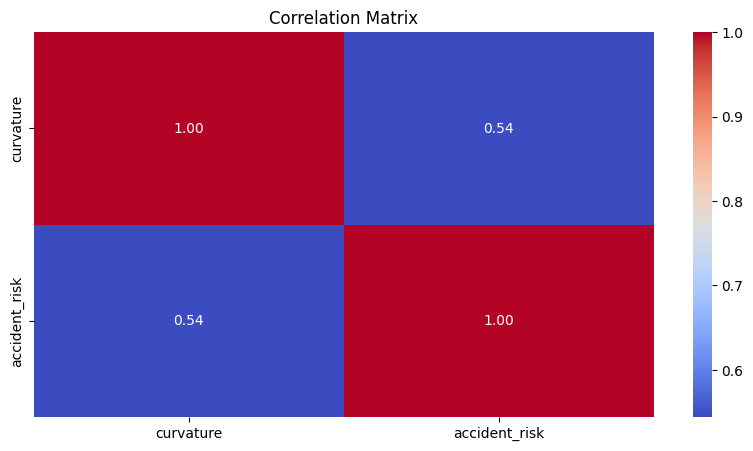

In [11]:
numerical_variables= df_train[['curvature', 'accident_risk']]
correlation_matrix= numerical_variables.corr()
plt.figure(figsize=(10, 5))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Feature processing**

In [12]:
#categorical variables in the dataset
categorical_variables= ['num_lanes', 'speed_limit','num_reported_accidents', 'road_type', 'lighting','weather','road_signs_present','public_road',
                        'time_of_day','holiday','school_season']
categorical_variables

['num_lanes',
 'speed_limit',
 'num_reported_accidents',
 'road_type',
 'lighting',
 'weather',
 'road_signs_present',
 'public_road',
 'time_of_day',
 'holiday',
 'school_season']

In [13]:
#Encoding categorical variables using one-hot encoding
df_train= pd.get_dummies(df_train, columns=categorical_variables, drop_first=True)
df_test= pd.get_dummies(df_test, columns=categorical_variables, drop_first=True)

In [14]:
#replacing True and False with 1 and 0
df_train=df_train.replace({True: 1, False: 0})
df_test=df_test.replace({True: 1, False: 0})

/tmp/ipykernel_13/751953346.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train=df_train.replace({True: 1, False: 0})
/tmp/ipykernel_13/751953346.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test=df_test.replace({True: 1, False: 0})


**Standardizing the data**

In [15]:
#Standardizing the features
scaler= StandardScaler()
X_train= df_train.drop('accident_risk', axis=1)
y_train= df_train['accident_risk']
X_test= df_test.copy()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)
X_train_scaled= pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled= pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

**Splitting the data**

In [16]:
#splitting the data into train and test set
X_train,X_test,y_train,y_test= train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)   

**Models used:**

In [17]:
#models with parameters
model1= LinearRegression()
model2= lgb.LGBMRegressor(objective='regression', random_state=42)
model3= xgb.XGBRegressor(objective='reg:squarederror', 
                             n_estimators=100,            
                             learning_rate=0.1,          
                             max_depth=4,                 
                             subsample=0.8,               
                             colsample_bytree=0.8,     
                             random_state=42)
model4= GradientBoostingRegressor(random_state=7)
final_model = VotingRegressor(estimators=[('lr', model1), ('lgb', model2),('xgb', model3),('gb', model4)], 
                              weights=[1,2,1,1])

**Model fitting**

In [18]:
#fitting the model to training data
final_model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 226
[LightGBM] [Info] Number of data points in the train set: 414203, number of used features: 25
[LightGBM] [Info] Start training from score 0.352605


VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('lgb',
                             LGBMRegressor(objective='regression',
                                           random_state=42)),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamm...
                                          interaction_constraints=None,
                                          learning_rate=0.1, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=4,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=100,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=42, ...)),
                            ('gb', GradientBoostingRegressor(random_state=7))],
                weights=[1, 2, 1, 1])

**Predictions:**

In [19]:
#predicting the values for target variable
y_pred= final_model.predict(X_test)

In [20]:
#calculating root mean squared error
rmse= sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error: {rmse}')

Root Mean Squared Error: 0.05673847836168656


In [21]:
#predicting values for test data
output= pd.DataFrame({'id':df_test.index, 'accident_risk': final_model.predict(X_test_scaled)})
output.to_csv('submission.csv', index= False)